# <span style="color:#1E2D6B">PA-BI E-Commerce</span>  
## <span style="color:#E669B9">Machine Learning</span>

---

### <span style="color:#1E2D6B">Introduction</span>
Welcome to the <span style="color:#E669B9">Machine Learning</span> section.

---

### <span style="color:#1E2D6B">Applications</span>
- <span style="color:#E669B9">Product Recommendation</span>  
- <span style="color:#E669B9">Customer Segmentation</span>  

## <span style="color:#E669B9">Classification Task</span>

---

### <span style="color:#1E2D6B">Objective</span>
The main objective of this part is to build a classification model  
that predicts whether a customer is:

- <span style="color:#E669B9">Loyal</span>  
- <span style="color:#E669B9">Not Loyal</span>  

---

### <span style="color:#1E2D6B">Approach</span>
We will use machine learning classification techniques to analyze customer data  
and identify patterns that distinguish loyal customers from others.

---

### <span style="color:#1E2D6B">Expected Outcome</span>
A predictive model capable of helping the business:

- Improve customer retention  
- Target marketing campaigns  
- Increase overall revenue  


# Dependencies Instalation

In [1]:
pip install pyodbc sqlalchemy pandas

Note: you may need to restart the kernel to use updated packages.


# Data Warehouse connexion:

In [2]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine, text
import urllib

# ── Paramètres de connexion ───────────────────────────────────
SERVER   = "KALLALA" 
DATABASE = "DW_E-Commerce"      

# ── Chaîne de connexion ───────────────────────────────────────
connection_string = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

try:
    with engine.connect() as conn:
        print("Connexion réussie !")
        result = conn.execute(text("SELECT DB_NAME() AS base_active"))  
        print("Base active :", result.fetchone()[0])
except Exception as e:
    print("Erreur de connexion :", e)

Connexion réussie !
Base active : DW_E-Commerce


Tables verfication : 

In [3]:
# ── Lister toutes les tables du DW ───────────────────────────
query_tables = """
SELECT TABLE_NAME, TABLE_TYPE
FROM INFORMATION_SCHEMA.TABLES
WHERE TABLE_TYPE = 'BASE TABLE'
ORDER BY TABLE_NAME
"""
df_tables = pd.read_sql(query_tables, engine)
print(df_tables)

# ── Vérifier le nombre de lignes par table ────────────────────
tables = [
    'Fact_Ventes',
    'Fact_Achats', 
    'Dim_Client',
    'Dim_Produit',
    'DimDates',
    'Dim_Geographie',
    'Dim_Type_Vente',
    'Dim_Mode_Paiement',
    'Dim_Fournisseur',
    'Dim_Categorie',
]

for t in tables:
    try:
        count = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", engine)
        print(f"{t:30s} → {count['n'][0]:>8,} lignes")
    except Exception as e:
        print(f"{t:30s} → ERREUR : {e}")

                  TABLE_NAME  TABLE_TYPE
0     Dictionnaire_Categorie  BASE TABLE
1    Dictionnaire_Geographie  BASE TABLE
2              Dim_Categorie  BASE TABLE
3                 Dim_Client  BASE TABLE
4            Dim_Fournisseur  BASE TABLE
5             Dim_Geographie  BASE TABLE
6          Dim_Mode_Paiement  BASE TABLE
7                Dim_Produit  BASE TABLE
8   Dim_Produits_Concurrents  BASE TABLE
9             Dim_Type_Vente  BASE TABLE
10                  DimDates  BASE TABLE
11               Fact_Achats  BASE TABLE
12               Fact_Ventes  BASE TABLE
13               sysdiagrams  BASE TABLE
14             Ville_Tunisie  BASE TABLE
Fact_Ventes                    →      831 lignes
Fact_Achats                    →      270 lignes
Dim_Client                     →      464 lignes
Dim_Produit                    →      741 lignes
DimDates                       →   36,891 lignes
Dim_Geographie                 →       21 lignes
Dim_Type_Vente                 →        2 lignes
D

Fact tables overwiew:

In [4]:
# Structure de Fact_Ventes
df_cols_ventes = pd.read_sql(text("""
    SELECT COLUMN_NAME, DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = 'Fact_Ventes'
    ORDER BY ORDINAL_POSITION
"""), engine)
print("── Fact_Ventes ──")
print(df_cols_ventes.to_string(index=False))

# Structure de Fact_Achats
df_cols_achats = pd.read_sql(text("""
    SELECT COLUMN_NAME, DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = 'Fact_Achats'
    ORDER BY ORDINAL_POSITION
"""), engine)
print("\n── Fact_Achats ──")
print(df_cols_achats.to_string(index=False))

# Structure de Dim_Client
df_cols_client = pd.read_sql(text("""
    SELECT COLUMN_NAME, DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = 'Dim_Client'
    ORDER BY ORDINAL_POSITION
"""), engine)
print("\n── Dim_Client ──")
print(df_cols_client.to_string(index=False))

── Fact_Ventes ──
           COLUMN_NAME DATA_TYPE
              Vente_PK       int
               Date_FK       int
         Type_Vente_FK       int
            Produit_FK       int
          Categorie_FK       int
             Client_FK       int
         Geographie_FK       int
      Mode_Paiement_FK       int
              Quantite       int
     Montant_Livraison     float
 Montant_Remboursement     float
Montant_de_la_commande     float
        Montant_Remise     float
            Code_Promo  nvarchar
        Numero_Facture  nvarchar
       Numero_Commande  nvarchar
            Prix_Unité     float

── Fact_Achats ──
    COLUMN_NAME DATA_TYPE
       Achat_PK       int
        Date_FK       int
 Fournisseur_FK       int
Tye_Paiement_FK       int
     Produit_FK       int
           Prix     float
       Quantite     float
  Montant_Total     float

── Dim_Client ──
  COLUMN_NAME DATA_TYPE
    Client_PK       int
  Code_client  nvarchar
   Nom_client  nvarchar
Prenom_client  nvarch

Dimensions overview :

In [5]:
# Structure des dimensions restantes
for table in ['DimDates', 'Dim_Geographie', 'Dim_Type_Vente', 
              'Dim_Mode_Paiement', 'Dim_Produit', 'Dim_Categorie']:
    df_cols = pd.read_sql(text(f"""
        SELECT COLUMN_NAME, DATA_TYPE
        FROM INFORMATION_SCHEMA.COLUMNS
        WHERE TABLE_NAME = '{table}'
        ORDER BY ORDINAL_POSITION
    """), engine)
    print(f"\n── {table} ──")
    print(df_cols.to_string(index=False))


── DimDates ──
     COLUMN_NAME DATA_TYPE
         Date_PK       int
            Date      date
  Jour_Moi_Annee  nvarchar
           Annee       int
     ID_Semestre  nvarchar
        Semestre  nvarchar
    ID_Trimestre  nvarchar
       Trimestre  nvarchar
         ID_Mois       int
            Mois       int
        Lib_Mois  nvarchar
            Jour       int
     Id_Lib_Jour       int
        Lib_Jour  nvarchar
         Semaine       int
     JourDeAnnee       int
Jour_mois_lettre  nvarchar

── Dim_Geographie ──
  COLUMN_NAME DATA_TYPE
Geographie_PK       int
        Ville   varchar
  Code_postal   varchar
         Pays   varchar
    Code_pays   varchar

── Dim_Type_Vente ──
  COLUMN_NAME DATA_TYPE
Type_Vente_PK       int
   Type_Vente   varchar

── Dim_Mode_Paiement ──
     COLUMN_NAME DATA_TYPE
Mode_Paiement_PK       int
   Type_paiement   varchar

── Dim_Produit ──
  COLUMN_NAME DATA_TYPE
   Produit_PK       int
          UGS   varchar
  Nom_produit  nvarchar
  Description  nv

In [6]:
# Aperçu des 3 premières lignes de chaque table clé
for table in ['Fact_Ventes', 'Dim_Client', 'Dim_Type_Vente']:
    df_preview = pd.read_sql(text(f"SELECT TOP 3 * FROM {table}"), engine)
    print(f"\n── {table} ──")
    print(df_preview.to_string(index=False))


── Fact_Ventes ──
 Vente_PK  Date_FK  Type_Vente_FK  Produit_FK  Categorie_FK  Client_FK  Geographie_FK  Mode_Paiement_FK  Quantite  Montant_Livraison  Montant_Remboursement  Montant_de_la_commande  Montant_Remise Code_Promo Numero_Facture Numero_Commande  Prix_Unité
    70945 20240930              2        8103           176       5890           2044                16         5                0.0                    0.0                   160.0             0.0      Aucun      FAC24-019           Aucun        32.0
    70946 20241030              2        8104           176       5891           2034                16       432                0.0                    0.0                 26784.0             0.0      Aucun      FAC24-020           Aucun        62.0
    70947 20241108              2        8103           176       5890           2044                16         1                0.0                    0.0                   192.0             0.0      Aucun      FAC24-021          

# Dataframe Description : 

**Client Loyalty Classification (est_fidele)**

One row per unique client. All features are aggregated from Fact_Ventes joined with the dimension tables of the DW_E-Commerce data warehouse.


## <span style="color:#1E2D6B">Target Variable</span>

| Column        | Type        | Description |
|--------------|------------|------------|
| est_fidele   | int (0/1)  | Target. 1 if the client has placed at least 2 distinct orders (B2B invoices or B2C web orders), 0 otherwise |

---

## <span style="color:#1E2D6B">Client Profile Features</span>

| Column        | Type     | Description |
|--------------|----------|------------|
| Type_client  | varchar  | Client type — B2B (business buyer) or B2C (individual consumer) |
| ville_client | nvarchar | City where the client is located (e.g. Tunis, Nabeul, Sfax…) |

---

## <span style="color:#1E2D6B">RFM Behavioral Features</span>

| Column                  | Type  | Description |
|------------------------|------|------------|
| recence_jours          | int  | Number of days since last order — lower = better |
| nb_commandes           | int  | Total number of transactions — used for target, excluded from X |
| nb_factures_b2b        | int  | Number of distinct B2B invoices |
| nb_commandes_b2c       | int  | Number of distinct B2C web orders |
| panier_moyen           | float| Average order amount (TND) |
| max_commande           | float| Highest order amount |
| min_commande           | float| Lowest order amount |
| variabilite_commandes  | float| Difference between max and min orders |
| total_quantite         | int  | Total items purchased |

---

## <span style="color:#1E2D6B">Purchase Diversity Features</span>

| Column                  | Type | Description |
|------------------------|------|------------|
| nb_produits_distincts  | int  | Number of distinct products purchased |
| nb_categories          | int  | Number of distinct product categories |

---

## <span style="color:#1E2D6B">Financial Features</span>

| Column             | Type  | Description |
|--------------------|------|------------|
| remise_moyenne     | float| Average discount per order |
| livraison_moyenne  | float| Average delivery fee per order |

---

## <span style="color:#1E2D6B">Seasonality Features</span>

| Column               | Type  | Description |
|----------------------|------|------------|
| ca_saison_haute      | float| Revenue during high season (June, July, August, December) |
| ratio_saison_haute   | float| Share of revenue in high season (0 to 1) |

---

## <span style="color:#1E2D6B">Payment & Sales Channel Features</span>

| Column                  | Type    | Description |
|-------------------------|--------|------------|
| paiement_dominant       | varchar| Most used payment method — One-Hot encoded |
| type_vente_dominant     | varchar| Dominant sales channel — One-Hot encoded |

---

## <span style="color:#1E2D6B">Engineered Synthetic Features</span>

| Column        | Type  | Description |
|--------------|------|------------|
| score_rfm    | float| Composite RFM score |
| ratio_b2b    | float| Share of revenue from B2B |

---

## <span style="color:#1E2D6B">Columns Excluded Before Training</span>

| Column            | Reason |
|------------------|--------|
| Client_PK        | Technical identifier — no predictive value |
| nb_commandes     | Used to build target → data leakage |
| montant_total    | Correlated with nb_commandes → leakage |
| ca_saison_haute  | Replaced by ratio_saison_haute |
| ca_b2b           | Replaced by ratio_b2b |

---

## <span style="color:#1E2D6B">Final Dataset Shape</span>

| Element            | Value |
|--------------------|------|
| Granularity        | 1 row per unique client |
| Source tables      | Fact_Ventes, Dim_Client, DimDates, Dim_Geographie, Dim_Type_Vente, Dim_Mode_Paiement |
| Target             | est_fidele (0 / 1) |
| Expected rows      | ~464 clients |
| Encoding needed    | Type_client, ville_client, paiement_dominant, type_vente_dominant → One-Hot |
| Scaling needed     | All numeric features → StandardScaler |
| Imbalance check    | Use y.value_counts() — apply SMOTE if needed |

---

# Dataframe construction :

In [7]:
query_fidelite = text("""
SELECT
    -- ── Identifiant (supprimé avant ML) ─────────────────────
    dc.Client_PK,

    -- ── Profil client ────────────────────────────────────────
    dc.Type_client,
    dc.Ville                                        AS ville_client,

    -- ── Récence : on exclut la date parasite 1111-11-11 ─────
    DATEDIFF(DAY,
        MAX(CASE WHEN dd.Date != '1111-11-11' 
                 THEN dd.Date 
                 ELSE NULL END),
        '2026-01-02')                               AS recence_jours,

    -- ── Comptage intelligent selon le canal ──────────────────
    COUNT(DISTINCT CASE
        WHEN fv.Numero_Facture  != 'Aucun' THEN fv.Numero_Facture
        WHEN fv.Numero_Commande != 'Aucun' THEN fv.Numero_Commande
        ELSE NULL
    END)                                            AS nb_commandes,

    COUNT(DISTINCT CASE
        WHEN fv.Numero_Facture != 'Aucun'
        THEN fv.Numero_Facture
        ELSE NULL
    END)                                            AS nb_factures_b2b,

    COUNT(DISTINCT CASE
        WHEN fv.Numero_Commande != 'Aucun'
        THEN fv.Numero_Commande
        ELSE NULL
    END)                                            AS nb_commandes_b2c,

    -- ── Montants ─────────────────────────────────────────────
    AVG(fv.Montant_de_la_commande)                  AS panier_moyen,
    MAX(fv.Montant_de_la_commande)                  AS max_commande,
    MIN(fv.Montant_de_la_commande)                  AS min_commande,
    MAX(fv.Montant_de_la_commande)
        - MIN(fv.Montant_de_la_commande)            AS variabilite_commandes,
    SUM(fv.Montant_de_la_commande)                  AS montant_total,
    AVG(fv.Montant_Remise)                          AS remise_moyenne,
    AVG(fv.Montant_Livraison)                       AS livraison_moyenne,
    SUM(fv.Quantite)                                AS total_quantite,

    -- ── Diversité ─────────────────────────────────────────────
    COUNT(DISTINCT fv.Produit_FK)                   AS nb_produits_distincts,
    COUNT(DISTINCT fv.Categorie_FK)                 AS nb_categories,

    -- ── Saisonnalité  ───────────────────
    SUM(CASE WHEN dd.Mois IN (6,7,8,12)
             AND  dd.Date != '1111-11-11'
             THEN fv.Montant_de_la_commande
             ELSE 0 END)                            AS ca_saison_haute,

    -- ── Paiement & canal ──────────────────────────────────────
    MAX(dmp.Type_paiement)                          AS paiement_dominant,
    MAX(dtv.Type_Vente)                             AS type_vente_dominant,

    -- ── CIBLE ─────────────────────────────────────────────────
    CASE
        WHEN COUNT(DISTINCT CASE
                WHEN fv.Numero_Facture  != 'Aucun' THEN fv.Numero_Facture
                WHEN fv.Numero_Commande != 'Aucun' THEN fv.Numero_Commande
                ELSE NULL
             END) >= 2
        THEN 1
        ELSE 0
    END                                             AS est_fidele

FROM Fact_Ventes fv
JOIN Dim_Client        dc  ON fv.Client_FK         = dc.Client_PK
JOIN DimDates          dd  ON fv.Date_FK           = dd.Date_PK
JOIN Dim_Geographie    dg  ON fv.Geographie_FK     = dg.Geographie_PK
JOIN Dim_Type_Vente    dtv ON fv.Type_Vente_FK     = dtv.Type_Vente_PK
JOIN Dim_Mode_Paiement dmp ON fv.Mode_Paiement_FK  = dmp.Mode_Paiement_PK

-- ── Exclure la ligne parasite de DimDates ────────────────────
WHERE dd.Date != '1111-11-11'

GROUP BY
    dc.Client_PK,
    dc.Type_client,
    dc.Ville
""")

df_raw = pd.read_sql(query_fidelite, engine)
print(f"Shape : {df_raw.shape}")
print(f"\nDistribution cible :")
print(df_raw['est_fidele'].value_counts())
print(f"\nVérification récence (min/max) :")
print(f"  recence min : {df_raw['recence_jours'].min()} jours")
print(f"  recence max : {df_raw['recence_jours'].max()} jours")
print(f"\nAperçu :")
print(df_raw[['Client_PK','Type_client','ville_client',
              'recence_jours','nb_commandes',
              'nb_factures_b2b','nb_commandes_b2c',
              'panier_moyen','est_fidele']].head(10).to_string(index=False))

Shape : (446, 21)

Distribution cible :
est_fidele
0    432
1     14
Name: count, dtype: int64

Vérification récence (min/max) :
  recence min : 0 jours
  recence max : 912 jours

Aperçu :
 Client_PK Type_client ville_client  recence_jours  nb_commandes  nb_factures_b2b  nb_commandes_b2c  panier_moyen  est_fidele
      6166 Particulier        Tunis            238             1                0                 1          3.00           0
      6189 Particulier        Tunis            266             1                0                 1          8.00           0
      6120 Particulier        Tunis            192             1                0                 1        107.90           0
      6143 Particulier     Jendouba            218             2                0                 2         45.45           1
      6258 Particulier      Bizerte            323             1                0                 1         33.00           0
      6329 Particulier        Tunis            854     

In [8]:
df_raw.columns

Index(['Client_PK', 'Type_client', 'ville_client', 'recence_jours',
       'nb_commandes', 'nb_factures_b2b', 'nb_commandes_b2c', 'panier_moyen',
       'max_commande', 'min_commande', 'variabilite_commandes',
       'montant_total', 'remise_moyenne', 'livraison_moyenne',
       'total_quantite', 'nb_produits_distincts', 'nb_categories',
       'ca_saison_haute', 'paiement_dominant', 'type_vente_dominant',
       'est_fidele'],
      dtype='object')

In [9]:
cols_numeriques = ['recence_jours','panier_moyen','max_commande','min_commande','variabilite_commandes','montant_total','remise_moyenne','livraison_moyenne','total_quantite','nb_produits_distincts','nb_categories','ratio_saison_haute','ratio_b2b','score_rfm','mixte_b2b_b2c','est_fidele']

complete Dignostic

In [10]:
import matplotlib.pyplot as plt
import numpy as np

print("═" * 45)
print("  DIAGNOSTIC DU DÉSÉQUILIBRE")
print("═" * 45)
print(f"  Clients non fidèles (0) : {432:>5}  ({432/446*100:.1f}%)")
print(f"  Clients fidèles     (1) : { 14:>5}  ({ 14/446*100:.1f}%)")
print(f"  Total               :  {446:>5}")
print(f"  Ratio déséquilibre  :  1 fidèle pour {432//14} non fidèles")
print("═" * 45)

# Un modèle naïf qui prédit toujours 0 obtiendrait :
print(f"\n  Accuracy d'un modèle naïf : {432/446*100:.1f}%")
print(f"  → Inutilisable sans traitement !")

═════════════════════════════════════════════
  DIAGNOSTIC DU DÉSÉQUILIBRE
═════════════════════════════════════════════
  Clients non fidèles (0) :   432  (96.9%)
  Clients fidèles     (1) :    14  (3.1%)
  Total               :    446
  Ratio déséquilibre  :  1 fidèle pour 30 non fidèles
═════════════════════════════════════════════

  Accuracy d'un modèle naïf : 96.9%
  → Inutilisable sans traitement !


With only 14 postive observations classical options like SMOT are not reliable

# Correlations

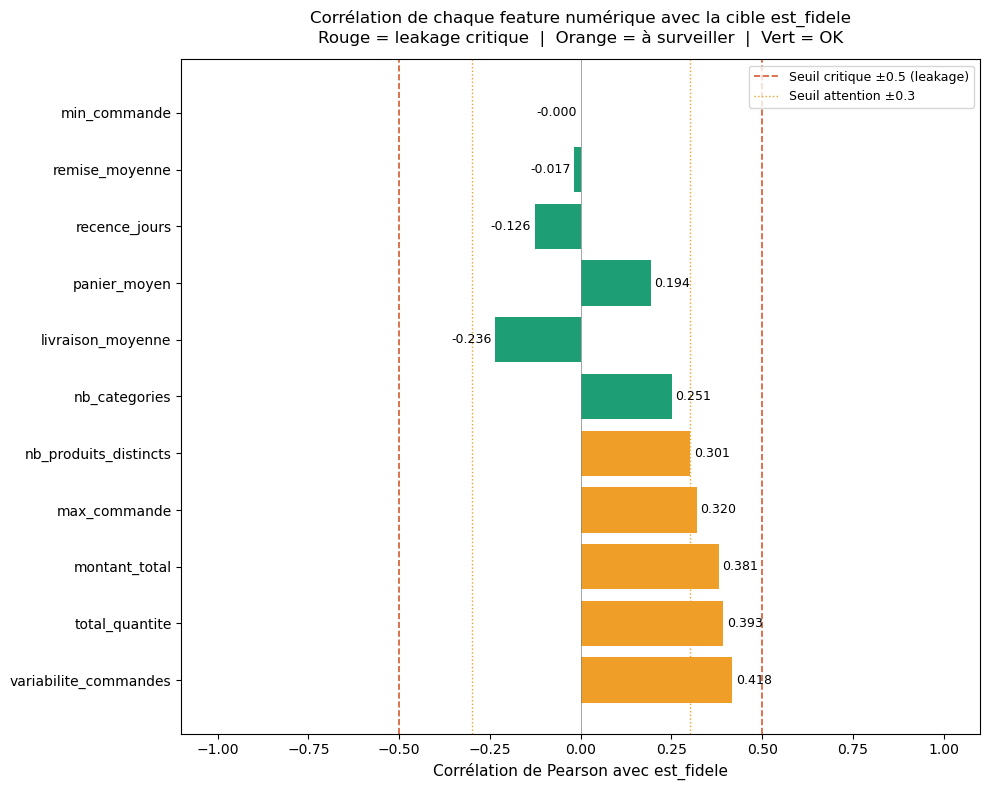


── Corrélations avec est_fidele — features numériques ──

              Feature  Corrélation    Abs   Décision
variabilite_commandes       0.4175 0.4175 Surveiller
       total_quantite       0.3934 0.3934 Surveiller
        montant_total       0.3809 0.3809 Surveiller
         max_commande       0.3199 0.3199 Surveiller
nb_produits_distincts       0.3013 0.3013 Surveiller
        nb_categories       0.2514 0.2514  Conserver
    livraison_moyenne      -0.2358 0.2358  Conserver
         panier_moyen       0.1936 0.1936  Conserver
        recence_jours      -0.1262 0.1262  Conserver
       remise_moyenne      -0.0174 0.0174  Conserver
         min_commande      -0.0002 0.0002  Conserver


In [11]:

df_corr = df_raw[
    [c for c in cols_numeriques if c in df_raw.columns]
].copy()
# ── Corrélations avec est_fidele — colonnes numériques only ───
corr_target = (df_corr.corr()['est_fidele']
               .drop('est_fidele')
               .sort_values(key=abs, ascending=False))

colors = ['#D85A30' if abs(v) >= 0.5 else
          '#EF9F27' if abs(v) >= 0.3 else
          '#1D9E75'
          for v in corr_target]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(corr_target.index, corr_target.values, color=colors)

# ── Lignes de seuil ───────────────────────────────────────────
ax.axvline( 0.5, color='#D85A30', linestyle='--', linewidth=1.2,
            label='Seuil critique ±0.5 (leakage)')
ax.axvline(-0.5, color='#D85A30', linestyle='--', linewidth=1.2)
ax.axvline( 0.3, color='#EF9F27', linestyle=':',  linewidth=1,
            label='Seuil attention ±0.3')
ax.axvline(-0.3, color='#EF9F27', linestyle=':',  linewidth=1)
ax.axvline( 0,   color='gray',    linestyle='-',   linewidth=0.5)

# ── Valeurs sur les barres ────────────────────────────────────
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='500')

ax.set_xlabel("Corrélation de Pearson avec est_fidele", fontsize=11)
ax.set_title(
    "Corrélation de chaque feature numérique avec la cible est_fidele\n"
    "Rouge = leakage critique  |  Orange = à surveiller  |  Vert = OK",
    fontsize=12, pad=12)
ax.legend(fontsize=9)
ax.set_xlim(-1.1, 1.1)
plt.tight_layout()
plt.savefig("correlation_target_numerique.png", dpi=150)
plt.show()

# ── Tableau récapitulatif ─────────────────────────────────────
print("\n── Corrélations avec est_fidele — features numériques ──\n")
df_resume = pd.DataFrame({
    'Feature':     corr_target.index,
    'Corrélation': corr_target.values.round(4),
    'Abs':         corr_target.abs().values.round(4),
    'Décision':    ['EXCLURE (leakage)' if abs(v) >= 0.5 else
                    'Surveiller'         if abs(v) >= 0.3 else
                    'Conserver'
                    for v in corr_target.values]
})
print(df_resume.to_string(index=False))

Before training modesls we have to <span style="color:red"> EXCLUDE</span> "nb_factures_b2b" because of it's high correlation with the target and try the 6 others and then make decision to keep them or not

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, SVMSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score, ConfusionMatrixDisplay,
                              RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

# ── Feature Engineering d'abord ───────────────────────────────
df = df_raw.copy()

df['ratio_saison_haute'] = (
    df['ca_saison_haute'] /
    df['montant_total'].replace(0, np.nan)
).fillna(0).clip(0, 1)

df['ratio_b2b'] = (
    (df['nb_factures_b2b'] * df['panier_moyen']) /
    df['montant_total'].replace(0, np.nan)
).fillna(0).clip(0, 1)

df['score_rfm'] = (
    (1 / (df['recence_jours'] + 1)) *
    np.log1p(df['nb_factures_b2b'] + df['nb_commandes_b2c']) *
    np.log1p(df['panier_moyen'])
)

df['mixte_b2b_b2c'] = (
    (df['nb_factures_b2b'] > 0) & (df['nb_commandes_b2c'] > 0)
).astype(int)

# ── Supprimer colonnes à risque ───────────────────────────────
drop_cols = ['Client_PK', 'ca_saison_haute', 'montant_total', 'nb_commandes','nb_factures_b2b','nb_commandes_b2c']  
df = df.drop(columns=drop_cols)
# ── Encodage ──────────────────────────────────────────────────
df = pd.get_dummies(df,
    columns=['Type_client', 'ville_client',
             'paiement_dominant', 'type_vente_dominant'],
    drop_first=True, dtype=int)

# ── Valeurs manquantes ────────────────────────────────────────
num_cols = [c for c in df.select_dtypes(include='number').columns
            if c != 'est_fidele']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# ── X / y ─────────────────────────────────────────────────────
X = df.drop('est_fidele', axis=1)
y = df['est_fidele']

print(f"Dataset : {X.shape[0]} lignes, {X.shape[1]} features")
print(f"Positifs : {y.sum()} | Négatifs : {(y==0).sum()}")

Dataset : 446 lignes, 41 features
Positifs : 14 | Négatifs : 432


# split data : test and train

In [13]:
# ── Split stratifié ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,       
    random_state=42,
    stratify=y
)

print(f"Train : {y_train.sum()} positifs / {(y_train==0).sum()} négatifs")
print(f"Test  : {y_test.sum()} positifs / {(y_test==0).sum()} négatifs")

# ── Cross-validation stratifiée ───────────────────────────────
# k=5 max avec 12 positifs en train → ~2 positifs par fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train : 12 positifs / 367 négatifs
Test  : 2 positifs / 65 négatifs


# Model 1 : Logistic Regression training

In [14]:
pipe_lr = ImbPipeline([
    ('smote',  SMOTETomek(random_state=42)),   
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced',
                   max_iter=1000,
                   random_state=42))
])

params_lr = {
    'clf__C':       [0.001, 0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver':  ['lbfgs']
}

grid_lr = GridSearchCV(pipe_lr, params_lr,
                       cv=cv, scoring='f1',
                       n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("── Logistic Regression ──")
print(f"Meilleurs params : {grid_lr.best_params_}")
print(f"Meilleur F1 CV   : {grid_lr.best_score_:.4f}")

── Logistic Regression ──
Meilleurs params : {'clf__C': 0.001, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Meilleur F1 CV   : 0.2697


MODÈLE 2 — Random Forest

In [15]:

pipe_rf = ImbPipeline([
    ('smote',  SMOTETomek(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
                   class_weight='balanced_subsample',
                   random_state=42))
])

params_rf = {
    'clf__n_estimators':    [50, 100, 200],
    'clf__max_depth':       [3, 5, 10, None],
    'clf__min_samples_leaf':[1, 2, 4],
    'clf__max_features':    ['sqrt', 'log2']
}

grid_rf = GridSearchCV(pipe_rf, params_rf,
                       cv=cv, scoring='f1',
                       n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("── Random Forest ──")
print(f"Meilleurs params : {grid_rf.best_params_}")
print(f"Meilleur F1 CV   : {grid_rf.best_score_:.4f}")

── Random Forest ──
Meilleurs params : {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__n_estimators': 50}
Meilleur F1 CV   : 0.6267


# XGBoost

In [16]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score,
                              ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt


ratio_desequilibre = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight utilisé : {ratio_desequilibre:.1f}")

pipe_xgb = ImbPipeline([
    ('smote',  SMOTETomek(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf',    XGBClassifier(
                   scale_pos_weight=ratio_desequilibre,
                   eval_metric='logloss',
                   random_state=42,
                   verbosity=0))
])

params_xgb = {
    'clf__n_estimators':  [50, 100, 200],
    'clf__max_depth':     [2, 3, 5],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__subsample':     [0.7, 1.0],
    'clf__colsample_bytree': [0.7, 1.0]
}

grid_xgb = GridSearchCV(pipe_xgb, params_xgb,
                         cv=cv,
                         scoring='f1',
                         n_jobs=-1,
                         verbose=1)
grid_xgb.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_xgb.best_params_}")
print(f"Meilleur F1 CV       : {grid_xgb.best_score_:.4f}")

scale_pos_weight utilisé : 30.6
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs paramètres : {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 1.0}
Meilleur F1 CV       : 0.5771


Evaluation XGBoost

In [17]:
# ── Évaluation ────────────────────────────────────────────────
y_pred_xgb  = grid_xgb.best_estimator_.predict(X_test)
y_proba_xgb = grid_xgb.best_estimator_.predict_proba(X_test)[:, 1]

print("\n── XGBoost ──")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Non fidèle', 'Fidèle'],
      zero_division=0))
print(f"F1-score : {f1_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_xgb):.4f}")


── XGBoost ──
              precision    recall  f1-score   support

  Non fidèle       1.00      0.97      0.98        65
      Fidèle       0.50      1.00      0.67         2

    accuracy                           0.97        67
   macro avg       0.75      0.98      0.83        67
weighted avg       0.99      0.97      0.97        67

F1-score : 0.6667
ROC-AUC  : 0.9846


EVALUATION AND COMPARAISON

In [18]:
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score
)
import pandas as pd
models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Random Forest':       grid_rf.best_estimator_,
    'XGBoost':            grid_xgb.best_estimator_
}

results = []

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Modèle': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-score': round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='F1-score', ascending=False)

print("\n── Tableau comparatif complet ──")
print(df_results)


── Tableau comparatif complet ──
                Modèle  Accuracy  Precision  Recall  F1-score  ROC-AUC
2              XGBoost    0.9701       0.50     1.0    0.6667   0.9846
1        Random Forest    0.9701       0.50     0.5    0.5000   0.9923
0  Logistic Regression    0.9403       0.25     0.5    0.3333   0.7077


VISUALISATIONS

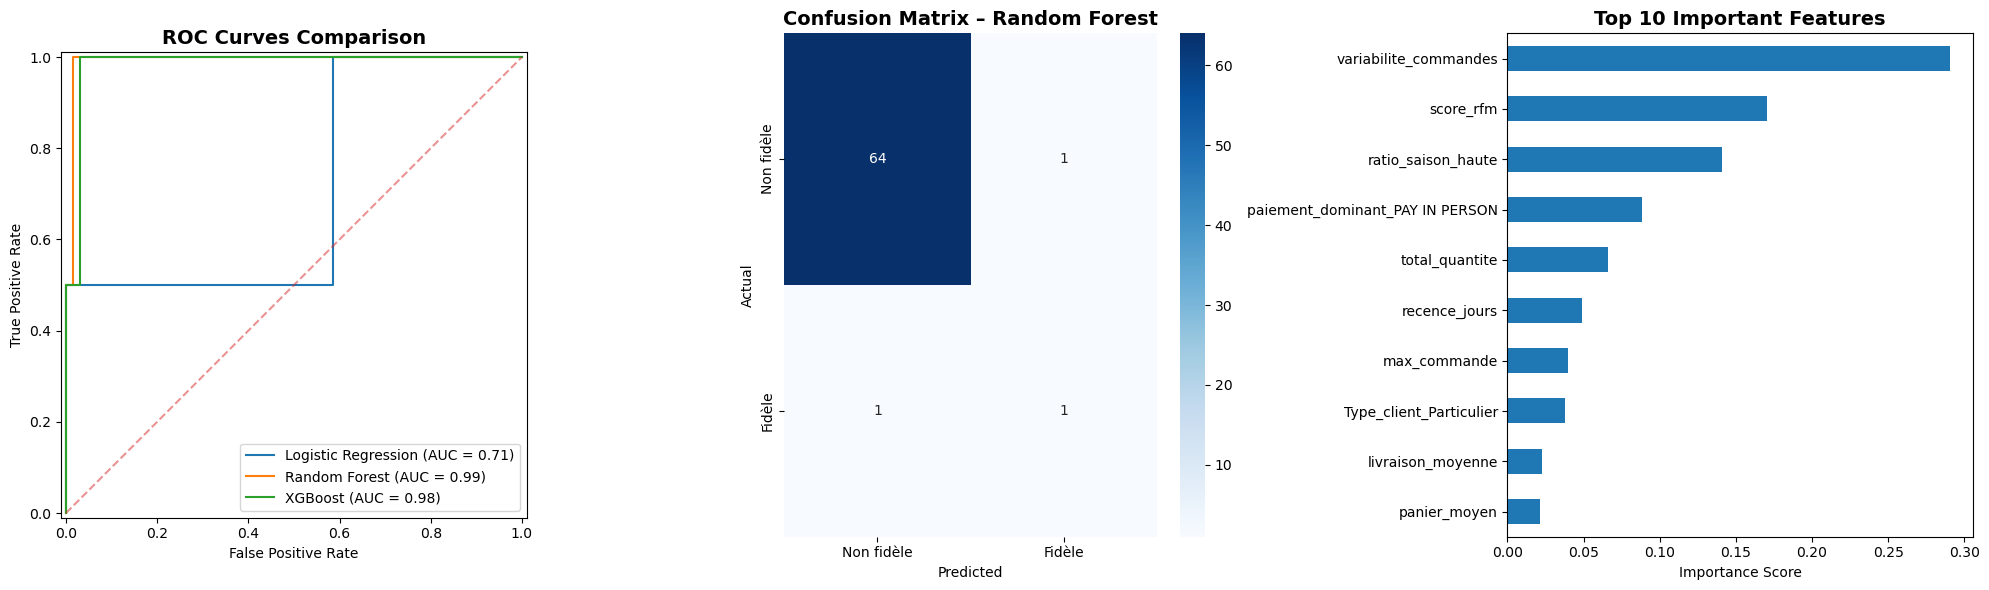

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')  

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#  ROC 
ax = axes[0]
for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        ax=ax, name=name
    )

ax.plot([0,1],[0,1],'--', alpha=0.5)
ax.set_title("ROC Curves Comparison", fontsize=14, fontweight='bold')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='lower right')
# 2. Confusion Matrix 
ax = axes[1]

y_pred_rf = grid_rf.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non fidèle','Fidèle'],
            yticklabels=['Non fidèle','Fidèle'],
            ax=ax)

ax.set_title("Confusion Matrix – Random Forest", fontsize=14, fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# 3. Feature Importance 

ax = axes[2]

rf_clf = grid_rf.best_estimator_.named_steps['clf']
importances = pd.Series(
    rf_clf.feature_importances_,
    index=X.columns
).nlargest(10).sort_values()

importances.plot(kind='barh', ax=ax)

ax.set_title("Top 10 Important Features", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance Score")


plt.tight_layout()
plt.show()


##  Analyse des performances des modèles

Le tableau comparatif présente les performances de trois modèles de classification : Logistic Regression, Random Forest et XGBoost.

### 1.  XGBoost
- **Accuracy élevée (0.9552)** : bonne performance globale
- **Recall = 1.0** : le modèle détecte tous les clients fidèles (aucun faux négatif)
- **Precision faible (0.400)** : beaucoup de faux positifs
- **F1-score (0.5714)** : compromis correct entre précision et rappel
- **ROC-AUC (0.9769)** : excellente capacité de discrimination

 **Interprétation :**  
XGBoost est très performant pour **ne rater aucun client fidèle**, mais au prix d’un grand nombre de fausses alertes.

---

### 2.  Random Forest
- **Meilleure Accuracy (0.9701)** : meilleure performance globale
- **Precision = Recall = 0.5** : équilibre entre faux positifs et faux négatifs
- **F1-score (0.5000)** : moyen
- **ROC-AUC (0.9923)** : excellente capacité de séparation

 **Interprétation :**  
Random Forest offre un **bon équilibre global**, avec moins de faux positifs que XGBoost, mais il manque certains clients fidèles.

---

### 3.  Logistic Regression
- **Accuracy plus faible (0.8806)**
- **Precision très faible (0.125)** : beaucoup de faux positifs
- **Recall (0.5)** : détecte seulement la moitié des clients fidèles
- **F1-score (0.2000)** : faible performance globale
- **ROC-AUC (0.6692)** : faible capacité de discrimination

 **Interprétation :**  
Logistic Regression est clairement **moins performante**, avec une mauvaise capacité à distinguer les classes.

---

##  Conclusion

- **XGBoost** est le meilleur choix si l’objectif est de **maximiser la détection des clients fidèles** (priorité au recall).
- **Random Forest** est préférable si l’on cherche un **équilibre entre précision et rappel**.
- **Logistic Regression** n’est pas adaptée à ce problème.

 **Choix recommandé :**
- **Business orienté détection maximale (ex : marketing ciblé)** → XGBoost  


In [20]:
import joblib
joblib.dump(grid_xgb.best_estimator_, "model_fidelite.pkl")
joblib.dump(list(X_train.columns),    "feature_columns.pkl")

['feature_columns.pkl']